<a href="https://colab.research.google.com/github/EnDFLab/EMCS_Project/blob/smart_meter_data_analytics/Copy_of_KU_SmartMeterDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#29th Jan 2025
**Introduction**
We have installed smart meters at the buildings of KU......

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn import tree
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.tree import DecisionTreeRegressor

import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
import math

energy = pd.read_csv('https://raw.githubusercontent.com/EnDFLab/EMCS_Project/refs/heads/smart_meter_data_analytics/data_with_one_hot_encoding/transformer_with_one_hot_encoding.csv')

In [17]:
energy.shape

(35136, 21)

In [18]:
energy.columns

Index(['timestamp', 'Load_consumed (kWh)', 'air_temp', 'holiday', 'Sunday',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'January',
       'February', 'March', 'April', 'May', 'June', 'July', 'August',
       'September', 'October', 'November'],
      dtype='object')

In [19]:
energy.head(2)

,timestamp,Load_consumed (kWh),air_temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,...,February,March,April,May,June,July,August,September,October,November
0,2024-01-01 00:00:00,NaN,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2024-01-01 00:15:00,0.0,8.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
#Removing initial and final missing datas from df

first_valid_index = energy[energy['Load_consumed (kWh)'] > 0].index.min()
last_valid_index = energy[energy['Load_consumed (kWh)'] > 0].index.max()

energy = energy.loc[first_valid_index:last_valid_index]

print(energy)

                 timestamp  Load_consumed (kWh)  air_temp  holiday  Sunday  \
20507  2024-08-01 14:45:00                27.91     26.33        0       0   
20508  2024-08-01 15:00:00                30.26     26.00        0       0   
20509  2024-08-01 15:15:00                27.45     25.33        0       0   
20510  2024-08-01 15:30:00                27.76     25.00        0       0   
20511  2024-08-01 15:45:00                25.17     24.00        0       0   
...                    ...                  ...       ...      ...     ...   
35036  2024-12-30 23:00:00                28.41      8.00        1       0   
35037  2024-12-30 23:15:00                24.74      8.00        1       0   
35038  2024-12-30 23:30:00                25.36      8.00        1       0   
35039  2024-12-30 23:45:00                23.40      8.00        1       0   
35040  2024-12-31 00:00:00                21.19      7.67        0       0   

       Monday  Tuesday  Wednesday  Thursday  Friday  ...  Febru

In [21]:
energy = energy.loc[:, (energy != 0).any(axis=0)]

print(energy)

                 timestamp  Load_consumed (kWh)  air_temp  holiday  Sunday  \
20507  2024-08-01 14:45:00                27.91     26.33        0       0   
20508  2024-08-01 15:00:00                30.26     26.00        0       0   
20509  2024-08-01 15:15:00                27.45     25.33        0       0   
20510  2024-08-01 15:30:00                27.76     25.00        0       0   
20511  2024-08-01 15:45:00                25.17     24.00        0       0   
...                    ...                  ...       ...      ...     ...   
35036  2024-12-30 23:00:00                28.41      8.00        1       0   
35037  2024-12-30 23:15:00                24.74      8.00        1       0   
35038  2024-12-30 23:30:00                25.36      8.00        1       0   
35039  2024-12-30 23:45:00                23.40      8.00        1       0   
35040  2024-12-31 00:00:00                21.19      7.67        0       0   

       Monday  Tuesday  Wednesday  Thursday  Friday  August  Se

In [22]:
energy['timestamp']=pd.to_datetime(energy['timestamp'])
energy['Load_consumed (kWh)']=energy['Load_consumed (kWh)'].fillna(0)
#Rename few columns
energy.rename(columns={'Load_consumed (kWh)':'load', 'air_temp':'temp'}, inplace=True)
energy.head()

,timestamp,load,temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,August,September,October,November
20507,2024-08-01 14:45:00,27.91,26.33,0,0,0,0,0,1,0,1,0,0,0
20508,2024-08-01 15:00:00,30.26,26.00,0,0,0,0,0,1,0,1,0,0,0
20509,2024-08-01 15:15:00,27.45,25.33,0,0,0,0,0,1,0,1,0,0,0
20510,2024-08-01 15:30:00,27.76,25.00,0,0,0,0,0,1,0,1,0,0,0
20511,2024-08-01 15:45:00,25.17,24.00,0,0,0,0,0,1,0,1,0,0,0


<Axes: xlabel='timestamp'>

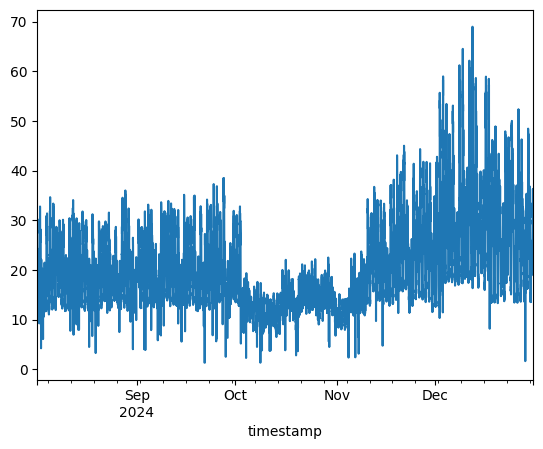

In [23]:
energy.set_index('timestamp',inplace=True)
energy['load'].plot()

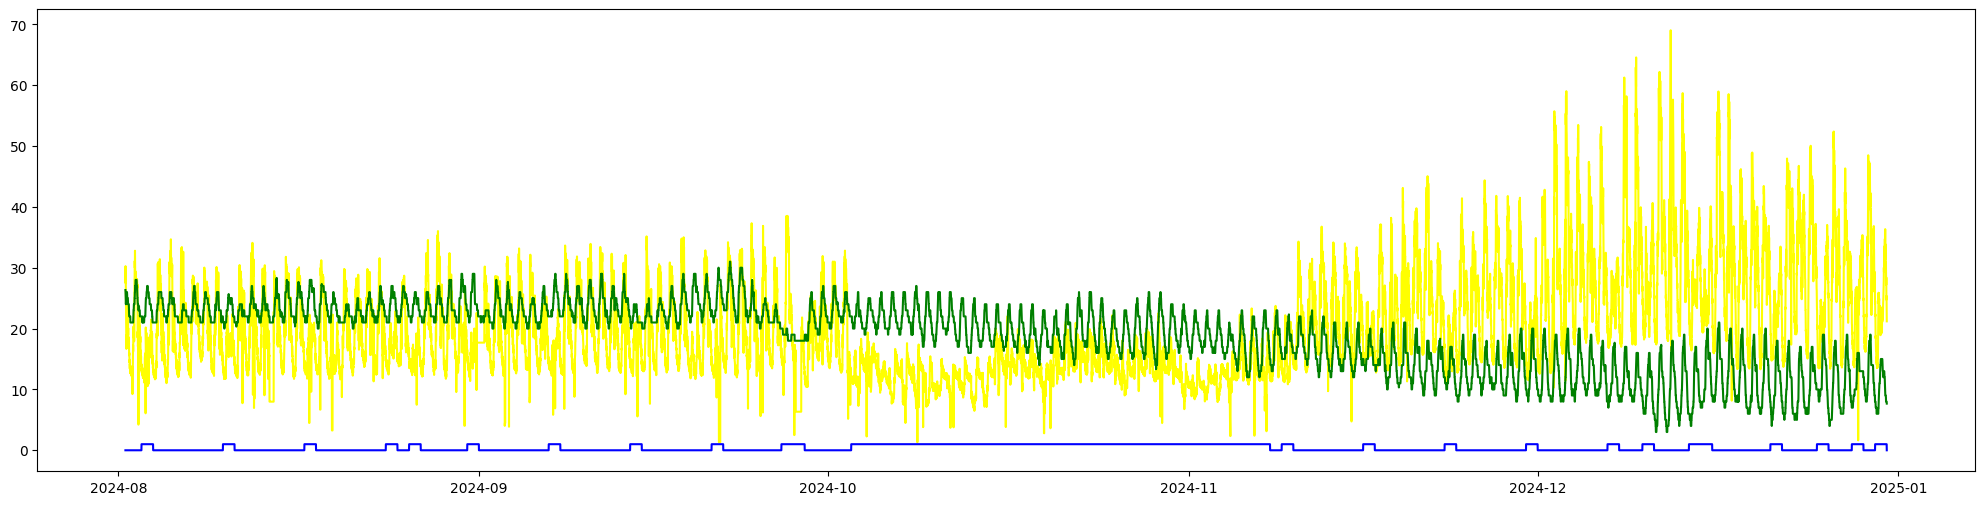

In [24]:
final=energy.copy()
fig, ax1 = plt.subplots(figsize=(25, 6))
ax1.plot( final['load'], color="yellow")
ax1.plot( final['temp'],  color="green")
ax1.plot(final['holiday'], color="blue")
plt.show()

It shows that the plotting would be better if we plot after the normalization.

# Defining Scale

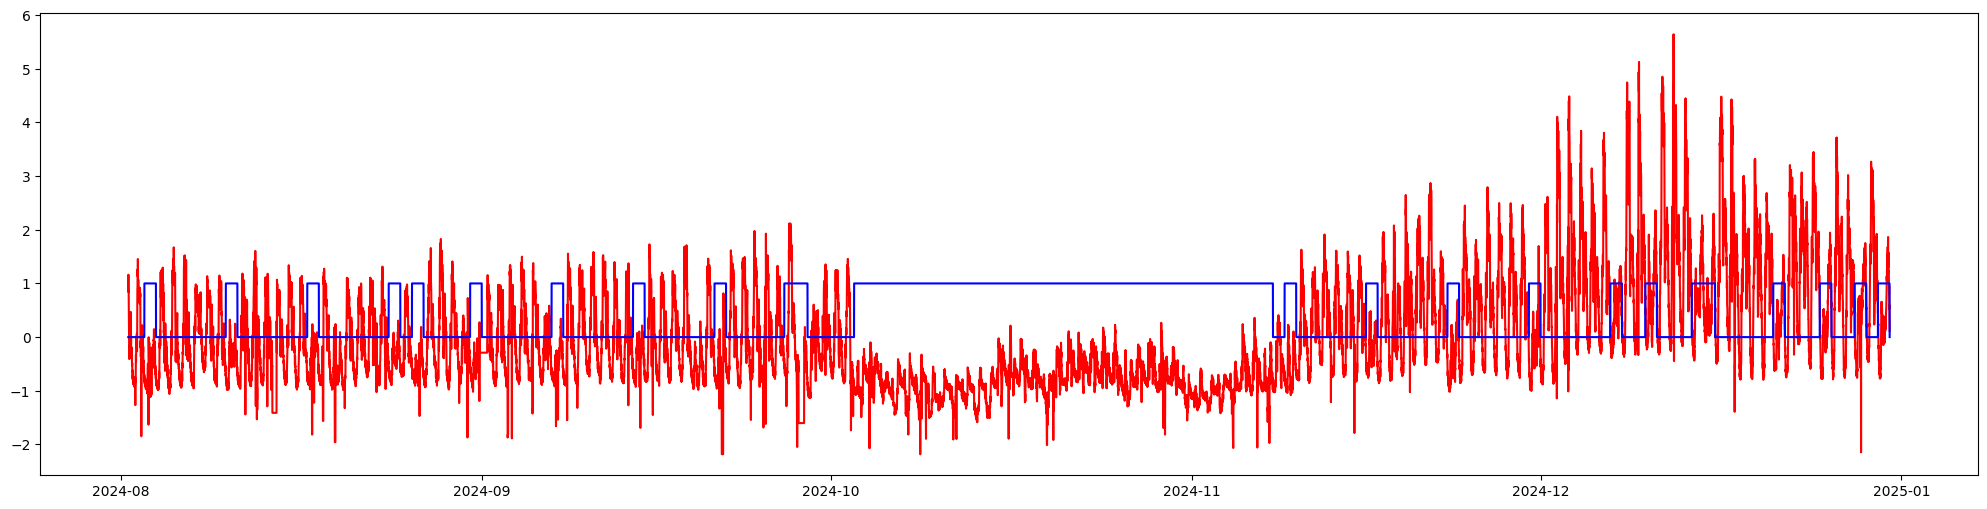

In [25]:

from sklearn.preprocessing import StandardScaler
np_vals = final['load'].values.reshape(-1, 1)
scaler = StandardScaler().fit(np_vals)
np_vals = scaler.transform(np_vals)

# assign normalized values to new column
final['load'] = np_vals.flatten()

fig, ax1 = plt.subplots(figsize=(25, 6))
ax1.plot( final['load'], color="red")
#ax1.plot( final['temp'],  color="green")
ax1.plot(final['holiday'], color="blue")
plt.show()

In [26]:
final[['load_shift_1','load_shift_2','load_shift_3']] = final['load'].shift(periods=[96, 96*2, 96*3],fill_value=0)
print(final)

                         load   temp  holiday  Sunday  Monday  Tuesday  \
timestamp                                                                
2024-08-01 14:45:00  0.890964  26.33        0       0       0        0   
2024-08-01 15:00:00  1.162499  26.00        0       0       0        0   
2024-08-01 15:15:00  0.837812  25.33        0       0       0        0   
2024-08-01 15:30:00  0.873632  25.00        0       0       0        0   
2024-08-01 15:45:00  0.574365  24.00        0       0       0        0   
...                       ...    ...      ...     ...     ...      ...   
2024-12-30 23:00:00  0.948737   8.00        1       0       1        0   
2024-12-30 23:15:00  0.524680   8.00        1       0       1        0   
2024-12-30 23:30:00  0.596319   8.00        1       0       1        0   
2024-12-30 23:45:00  0.369847   8.00        1       0       1        0   
2024-12-31 00:00:00  0.114488   7.67        0       0       0        1   

                     Wednesday  Thurs

<Axes: >

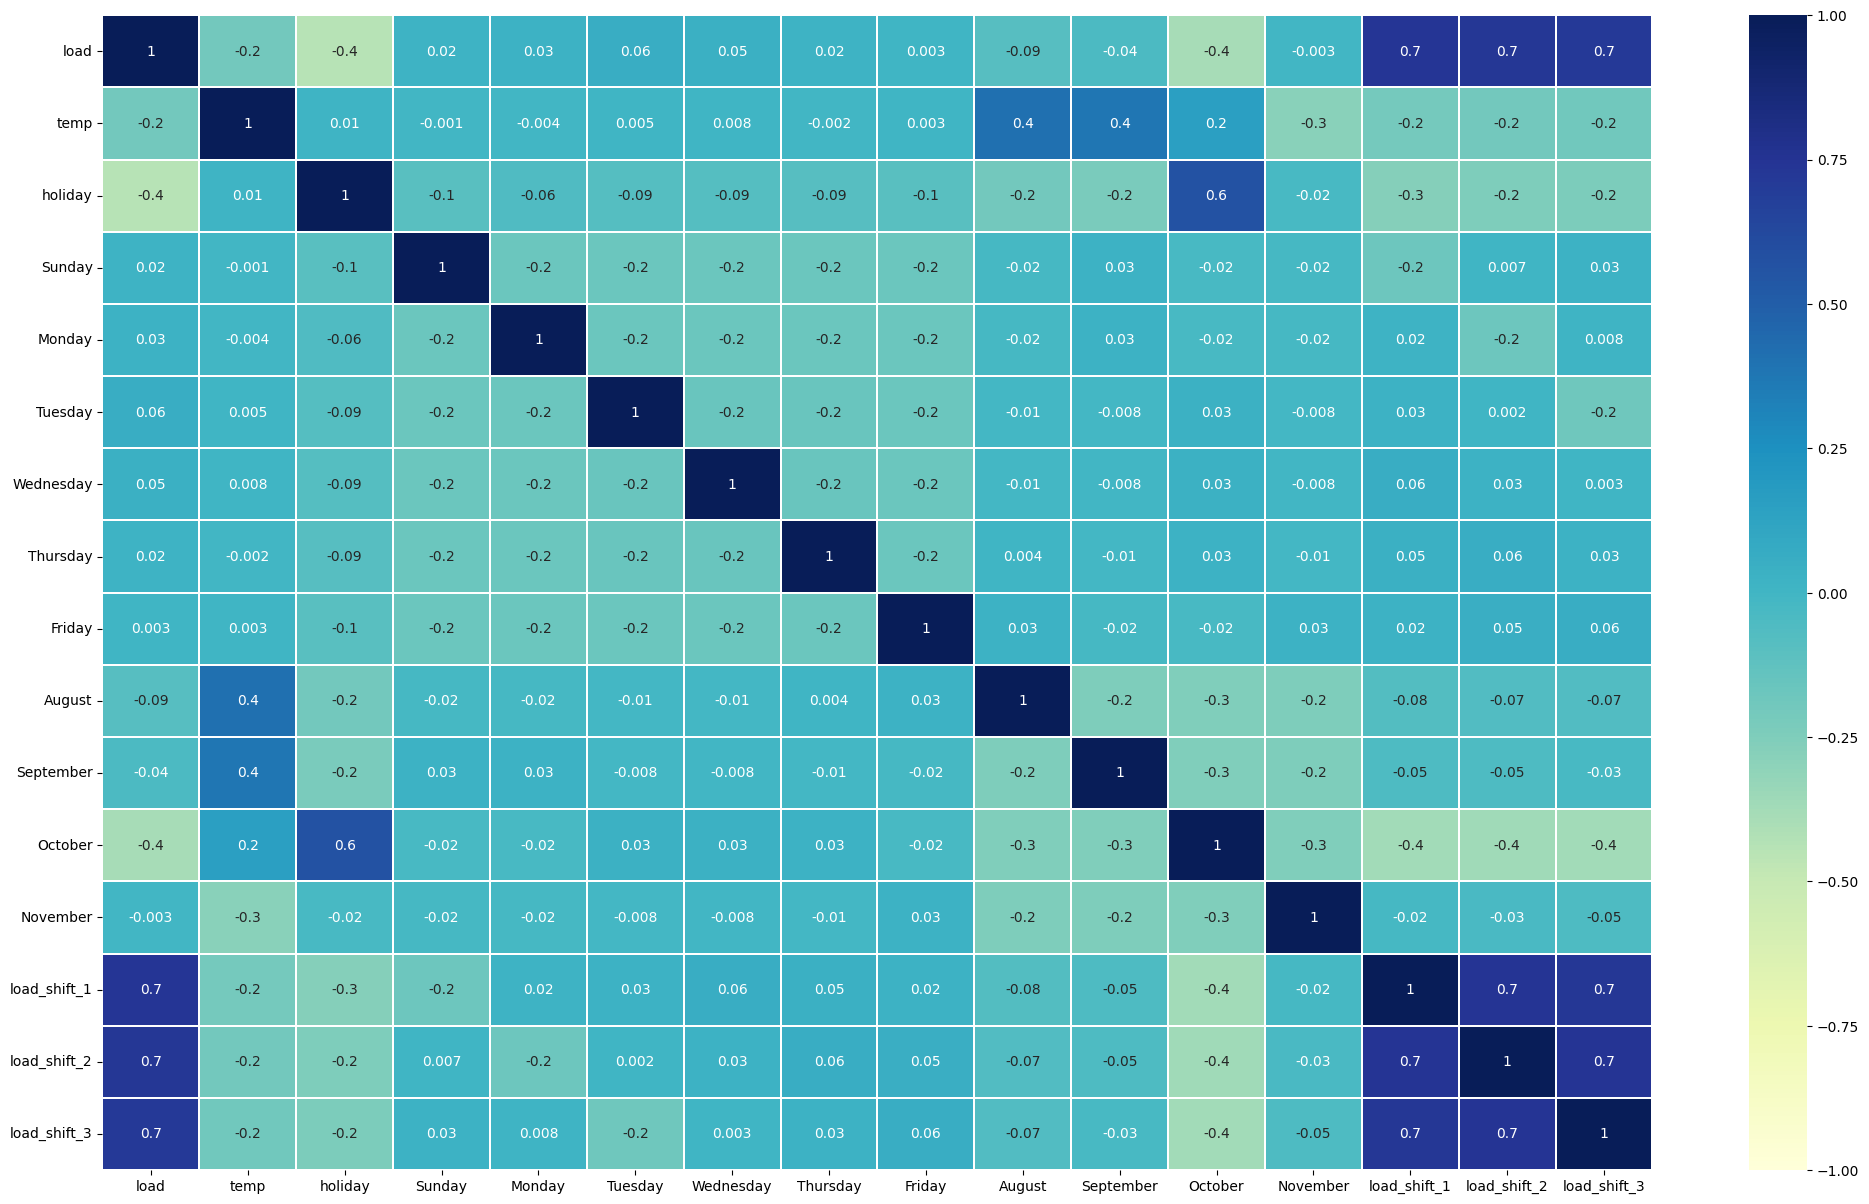

In [27]:
import seaborn as sns
final_corr = final.corr()
fig, ax = plt.subplots(figsize=(25,15))
sns.heatmap(final_corr, cmap="YlGnBu", linewidths=0.3, annot=True, fmt='.1g', vmin=-1, vmax=1, center= 0, ax=ax)

# Feature Selection

In [28]:
#Lets find feature variables
final_corr.reset_index(inplace=True)
feature_list = [j for i, j in zip(final_corr['load'], final_corr['index']) if abs(i) > 0.1]
feature_list

['load',
 'temp',
 'holiday',
 'October',
 'load_shift_1',
 'load_shift_2',
 'load_shift_3']

In [33]:
#List of column with feature lists given by correlation graph

final_colums=['load', 'temp', 'holiday', 'October','load_shift_1','load_shift_2','load_shift_3']

In [30]:
final

,load,temp,holiday,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,August,September,October,November,load_shift_1,load_shift_2,load_shift_3
timestamp,,,,,,,,,,,,,,,,
2024-08-01 14:45:00,0.890964,26.33,0,0,0,0,0,1,0,1,0,0,0,0.000000,0.000000,0.000000
2024-08-01 15:00:00,1.162499,26.00,0,0,0,0,0,1,0,1,0,0,0,0.000000,0.000000,0.000000
2024-08-01 15:15:00,0.837812,25.33,0,0,0,0,0,1,0,1,0,0,0,0.000000,0.000000,0.000000
2024-08-01 15:30:00,0.873632,25.00,0,0,0,0,0,1,0,1,0,0,0,0.000000,0.000000,0.000000
2024-08-01 15:45:00,0.574365,24.00,0,0,0,0,0,1,0,1,0,0,0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 23:00:00,0.948737,8.00,1,0,1,0,0,0,0,0,0,0,0,0.730353,0.934872,0.557033
2024-12-30 23:15:00,0.524680,8.00,1,0,1,0,0,0,0,0,0,0,0,0.856300,0.946426,0.451885
2024-12-30 23:30:00,0.596319,8.00,1,0,1,0,0,0,0,0,0,0,0,0.604407,0.554722,0.681824


# Train Test Split

In [34]:
print("Minimum date:", final.index.min())
print("Maximum date:", final.index.max())

Minimum date: 2024-08-01 14:45:00
Maximum date: 2024-12-31 00:00:00


In [35]:
#Lets split train and test
train = final[final.index < "2024-11-01"][final_colums] # Corrected: Use boolean indexing directly on the index
test = final[final.index >= "2024-11-01"][final_colums] # Corrected: Use boolean indexing directly on the index

In [36]:
train.head(3)

,load,temp,holiday,October,load_shift_1,load_shift_2,load_shift_3
timestamp,,,,,,,
2024-08-01 14:45:00,0.890964,26.33,0,0,0.0,0.0,0.0
2024-08-01 15:00:00,1.162499,26.00,0,0,0.0,0.0,0.0
2024-08-01 15:15:00,0.837812,25.33,0,0,0.0,0.0,0.0


In [37]:
test.head(3)

,load,temp,holiday,October,load_shift_1,load_shift_2,load_shift_3
timestamp,,,,,,,
2024-11-01 00:00:00,-1.042138,17.0,1,0,-0.936990,-0.837620,-0.917347
2024-11-01 00:15:00,-1.127643,17.0,1,0,-0.828376,-0.737094,-0.835309
2024-11-01 00:30:00,-1.131109,17.0,1,0,-0.940457,-0.852641,-0.946234


# Accuracy Function

In [38]:
def accuracy_function(y, y_pred):
    yhat_lower = []
    yhat_upper = []
    y_bin = [1]*len(y)
    y_pred_bin = []
    for i in y:
        yhat_lower.append(i-0.6)
        yhat_upper.append(i+0.6)
    for i, j, k in zip(yhat_lower, yhat_upper, y_pred):
        if k< j and k>i:
            y_pred_bin.append(1)
        else:
            y_pred_bin.append(0)
    acc_score = accuracy_score(y_bin, y_pred_bin)
    return acc_score

In [39]:
#train.reset_index()

# Spliting Test and Train

In [41]:
#Lets split train and test
train = final[final.index < "2024-12-01"][final_colums] # Corrected: Use boolean indexing directly on the index
test = final[final.index >= "2024-12-01"][final_colums] # Corrected: Use boolean indexing directly on the index

# Ensure X_train and X_test have the same columns and order
feature_cols = [col for col in final_colums if col != 'load']


#feature_cols = ['temp', 'holiday', 'June', 'July', 'August', 'October'] # list of features in desired order
X_train = train[feature_cols]
y_train = train['load']

X_test = test[feature_cols]
y_test = test['load']


print(test.head())
print(X_test.head())
print(y_test.head())
print(train.head())
print(X_train.head())
print(y_train.head())

                         load  temp  holiday  October  load_shift_1  \
timestamp                                                             
2024-12-01 00:00:00 -0.555685  10.0        0        0     -0.451693   
2024-12-01 00:15:00 -0.407785  10.0        0        0     -0.398541   
2024-12-01 00:30:00 -0.611148  10.0        0        0     -0.715140   
2024-12-01 00:45:00 -0.705896  10.0        0        0     -0.692031   
2024-12-01 01:00:00 -0.718606   9.0        0        0     -0.663144   

                     load_shift_2  load_shift_3  
timestamp                                        
2024-12-01 00:00:00     -0.170913     -0.247175  
2024-12-01 00:15:00     -0.408940     -0.157048  
2024-12-01 00:30:00     -0.308414     -0.319969  
2024-12-01 00:45:00     -0.460937     -0.437827  
2024-12-01 01:00:00     -0.445915     -0.368499  
                     temp  holiday  October  load_shift_1  load_shift_2  \
timestamp                                                                 
20

# Train Model

In [42]:
def evaluate_model(name,model, X_train, y_train, X_test, y_test):
    # Training Time
    start_time_train = time.process_time()
    model.fit(X_train, y_train)
    training_time = time.process_time() - start_time_train
    print(f"Training Time: {training_time:.5f} seconds")

    # Training MSE and RMSE
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = math.sqrt(mse_train)
    print(f"Training MSE: {mse_train:.5f}")
    print(f"Training RMSE: {rmse_train:.5f}")

    # Training MAPE
    mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
    print(f"Training MAPE: {mape_train:.5f}%")

    # Testing Time
    start_time_test = time.process_time()
    y_test_pred = model.predict(X_test)
    testing_time = time.process_time() - start_time_test
    print(f"Testing Time: {testing_time:.5f} seconds")

    # Testing RMSE
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = math.sqrt(mse_test)
    print(f"Testing RMSE: {rmse_test:.5f}")

    # Testing MAPE
    mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
    print(f"Testing MAPE: {mape_test:.5f}%")

    acc_score = accuracy_function(y_test, y_test_pred)
    print(f"Accuracy Score: {acc_score:.5f}%")

    comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
    })

    fig, ax1 = plt.subplots(figsize=(25, 6))
    ax1.plot( comparison_df['Actual'], color="red")
    ax1.plot( comparison_df['Predicted'],  color="green")
    plt.legend(['Actual', 'Predicted'])
    plt.title(f'Actutal vs Predicted for {name} Model')
    plt.show()


    comparison_df.to_csv(name + '.csv')
    print("\nActual vs Predicted Values:")
    print(comparison_df.head(10))  # Show only first 10 rows for readability




In [ ]:
#Lets split train and test
#train = final[final.index < "2024-11-01"][final_colums] # Corrected: Use boolean indexing directly on the index
#test = final[final.index >= "2024-11-01"][final_colums] # Corrected: Use boolean indexing directly on the index

#test.reset_index(inplace=True)
#X_test=test.iloc[:,2:]
#y_test=test.iloc[:,1]

#X_train = train.iloc[:,2:]
#y_train = train.iloc[:,1]

#print(test.head())
#print(X_test.head())
#print(y_test.head())
#print(train.head())
#rint(X_train.head())
#print(y_train.head())


In [ ]:

#X_train = train.drop(["load", "timestamp"], axis=1)
#y_train = train["load"]
#X_test = test.drop(["load", "timestamp"], axis=1)
#y_test = test["load"]
#X_train.shape, y_train.shape, X_test.shape, y_test.shape

Evaluating Linear Regression...

Training Time: 0.01585 seconds
Training MSE: 0.20589
Training RMSE: 0.45375
Training MAPE: 161.30674%
Testing Time: 0.00353 seconds
Testing RMSE: 0.88448
Testing MAPE: 202.01511%
Accuracy Score: 0.64040%


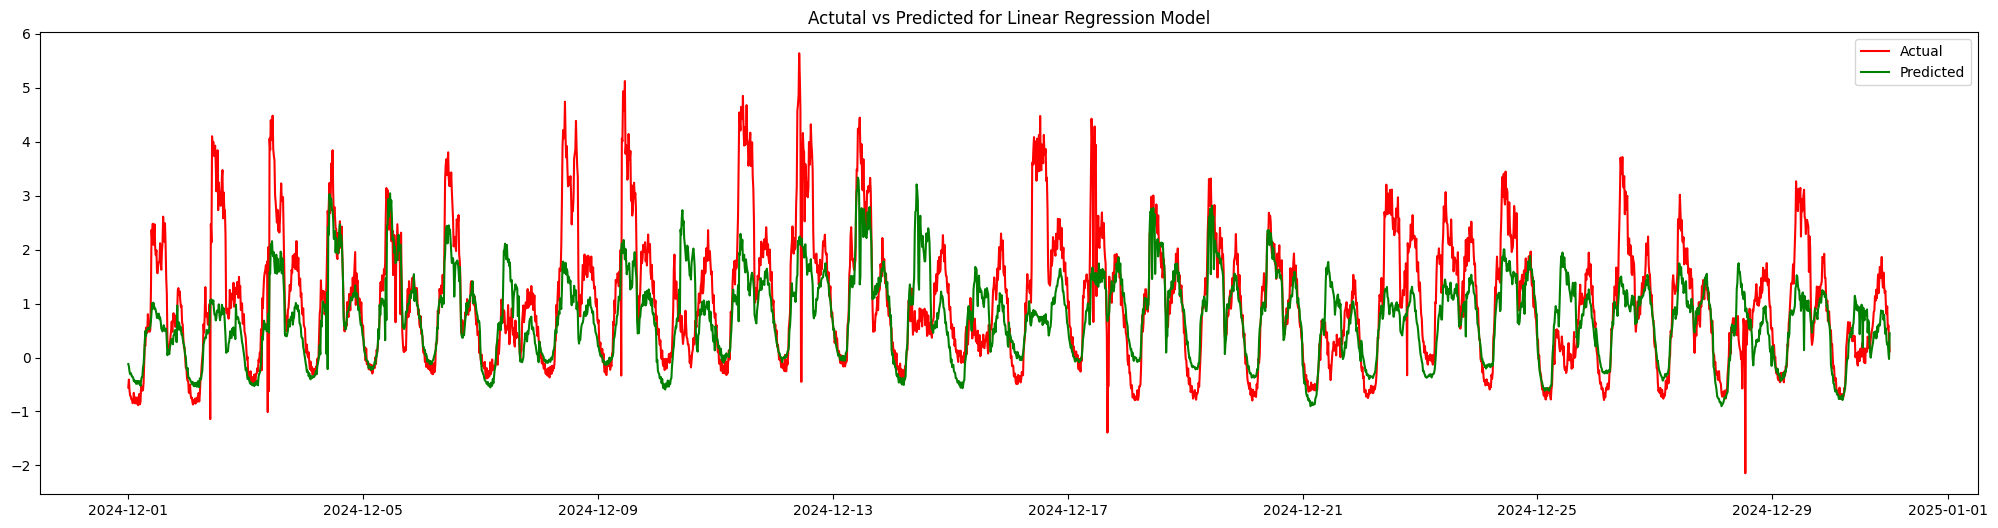


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.120741
2024-12-01 00:15:00 -0.407785  -0.167490
2024-12-01 00:30:00 -0.611148  -0.257188
2024-12-01 00:45:00 -0.705896  -0.308439
2024-12-01 01:00:00 -0.718606  -0.286694
2024-12-01 01:15:00 -0.775224  -0.315120
2024-12-01 01:30:00 -0.771758  -0.353737
2024-12-01 01:45:00 -0.846864  -0.356677
2024-12-01 02:00:00 -0.831842  -0.372371
2024-12-01 02:15:00 -0.655056  -0.435419
Evaluating SVR...

Training Time: 6.13151 seconds
Training MSE: 0.20077
Training RMSE: 0.44807
Training MAPE: 166.29329%
Testing Time: 1.12942 seconds
Testing RMSE: 0.87446
Testing MAPE: 453.84009%
Accuracy Score: 0.64596%


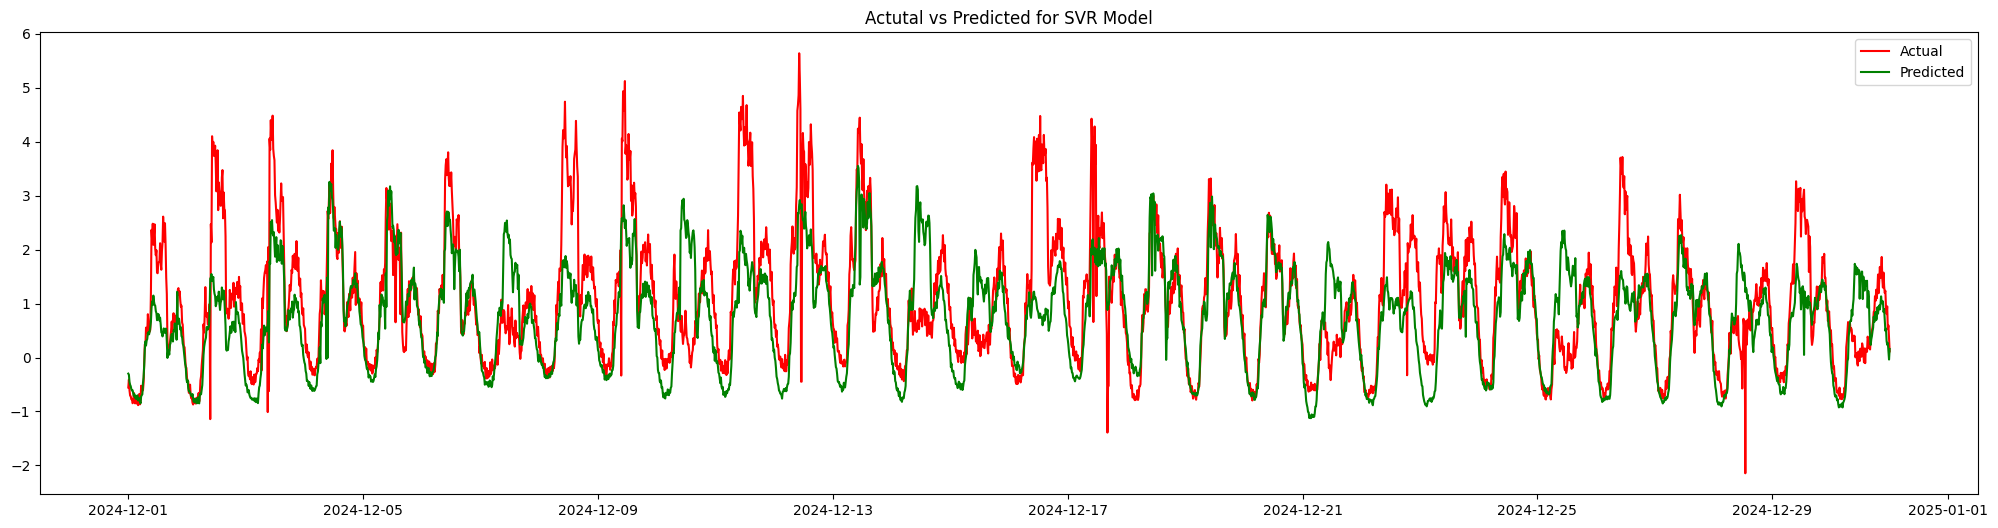


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.298002
2024-12-01 00:15:00 -0.407785  -0.319475
2024-12-01 00:30:00 -0.611148  -0.457105
2024-12-01 00:45:00 -0.705896  -0.506235
2024-12-01 01:00:00 -0.718606  -0.531570
2024-12-01 01:15:00 -0.775224  -0.586043
2024-12-01 01:30:00 -0.771758  -0.610149
2024-12-01 01:45:00 -0.846864  -0.605312
2024-12-01 02:00:00 -0.831842  -0.654596
2024-12-01 02:15:00 -0.655056  -0.707113
Evaluating Decision Tree...

Training Time: 0.09719 seconds
Training MSE: 0.00096
Training RMSE: 0.03097
Training MAPE: 0.58776%
Testing Time: 0.00168 seconds
Testing RMSE: 0.94545
Testing MAPE: 317.52860%
Accuracy Score: 0.60951%


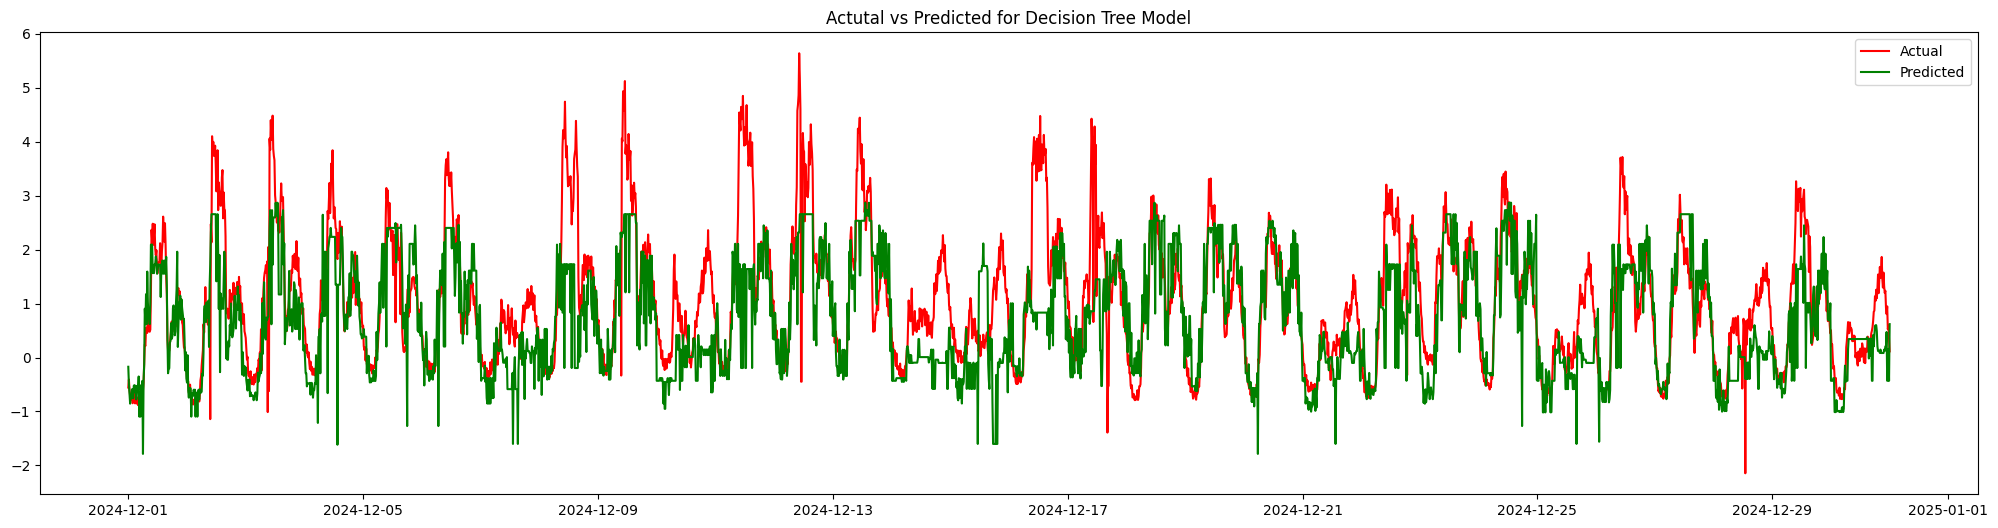


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.170913
2024-12-01 00:15:00 -0.407785  -0.492134
2024-12-01 00:30:00 -0.611148  -0.680476
2024-12-01 00:45:00 -0.705896  -0.854952
2024-12-01 01:00:00 -0.718606  -0.698963
2024-12-01 01:15:00 -0.775224  -0.754426
2024-12-01 01:30:00 -0.771758  -0.589194
2024-12-01 01:45:00 -0.846864  -0.589194
2024-12-01 02:00:00 -0.831842  -0.754426
2024-12-01 02:15:00 -0.655056  -0.523332
Evaluating ANN...

Training Time: 8.92734 seconds
Training MSE: 0.14524
Training RMSE: 0.38110
Training MAPE: 209.08915%
Testing Time: 0.00668 seconds
Testing RMSE: 0.74147
Testing MAPE: 228.30509%
Accuracy Score: 0.67234%


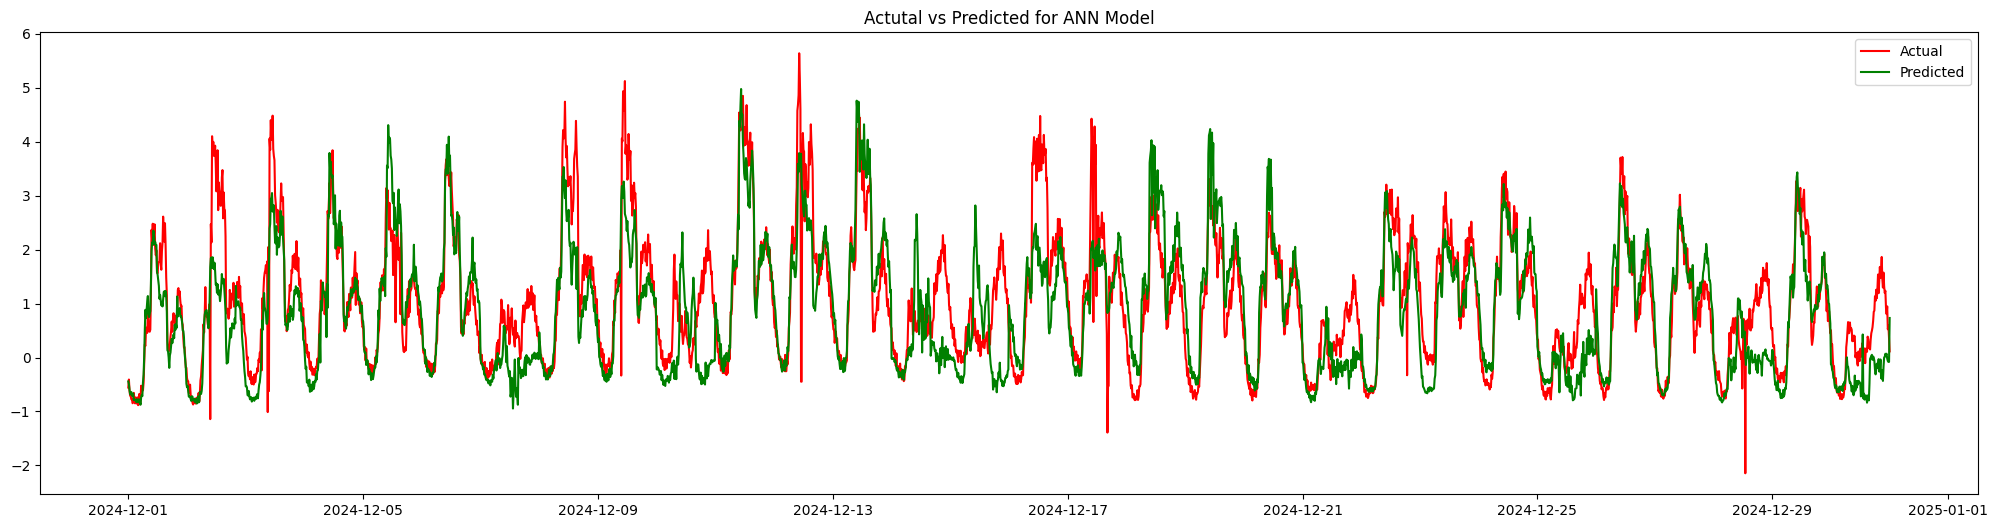


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.443518
2024-12-01 00:15:00 -0.407785  -0.494726
2024-12-01 00:30:00 -0.611148  -0.601880
2024-12-01 00:45:00 -0.705896  -0.681657
2024-12-01 01:00:00 -0.718606  -0.652223
2024-12-01 01:15:00 -0.775224  -0.639716
2024-12-01 01:30:00 -0.771758  -0.707581
2024-12-01 01:45:00 -0.846864  -0.714486
2024-12-01 02:00:00 -0.831842  -0.666480
2024-12-01 02:15:00 -0.655056  -0.789810
Evaluating Random Forest...

Training Time: 6.13852 seconds
Training MSE: 0.01477
Training RMSE: 0.12152
Training MAPE: 63.70906%
Testing Time: 0.05500 seconds
Testing RMSE: 0.85653
Testing MAPE: 206.12343%
Accuracy Score: 0.63797%


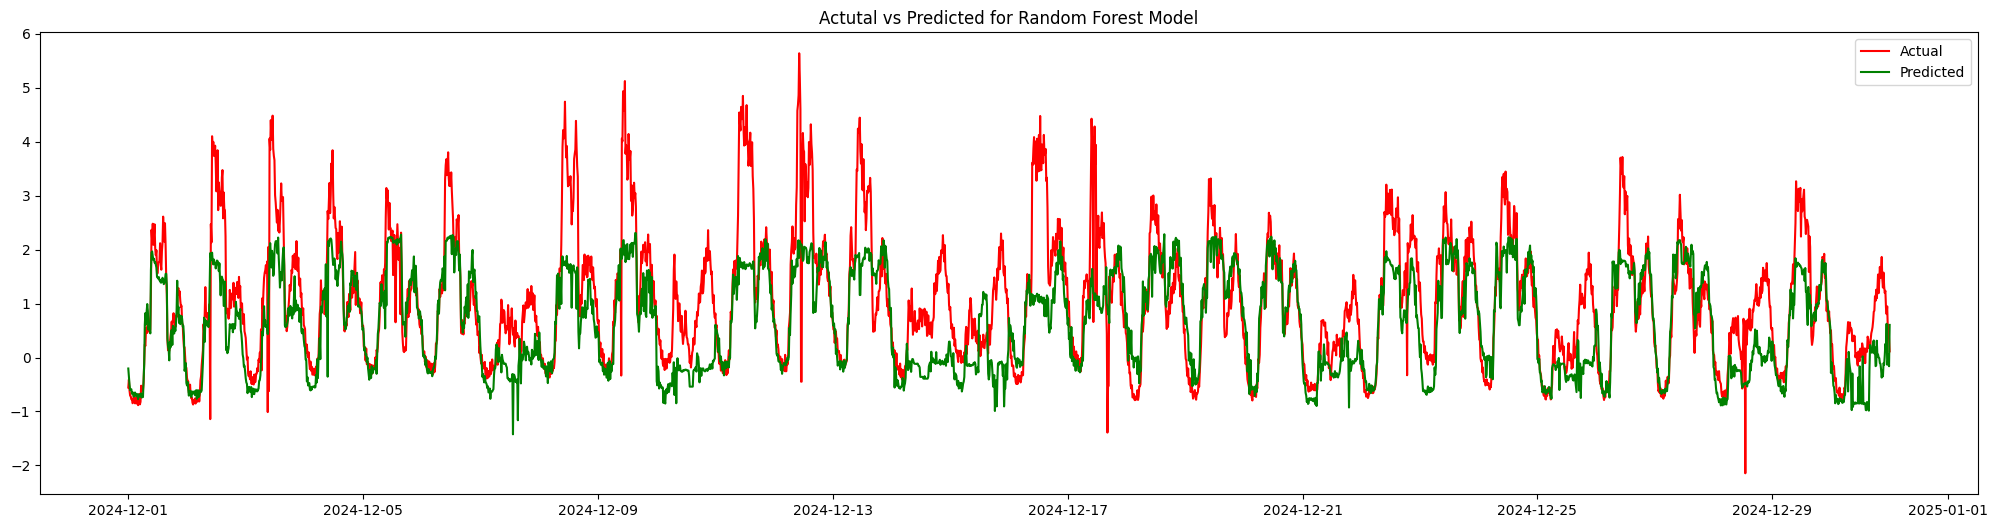


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.203244
2024-12-01 00:15:00 -0.407785  -0.358238
2024-12-01 00:30:00 -0.611148  -0.499991
2024-12-01 00:45:00 -0.705896  -0.602886
2024-12-01 01:00:00 -0.718606  -0.590523
2024-12-01 01:15:00 -0.775224  -0.586941
2024-12-01 01:30:00 -0.771758  -0.672734
2024-12-01 01:45:00 -0.846864  -0.642137
2024-12-01 02:00:00 -0.831842  -0.686126
2024-12-01 02:15:00 -0.655056  -0.722466
Evaluating Xtreme Gradient Boost...

Training Time: 0.36395 seconds
Training MSE: 0.04514
Training RMSE: 0.21247
Training MAPE: 118.31530%
Testing Time: 0.02180 seconds
Testing RMSE: 0.89892
Testing MAPE: 374.12310%
Accuracy Score: 0.61368%


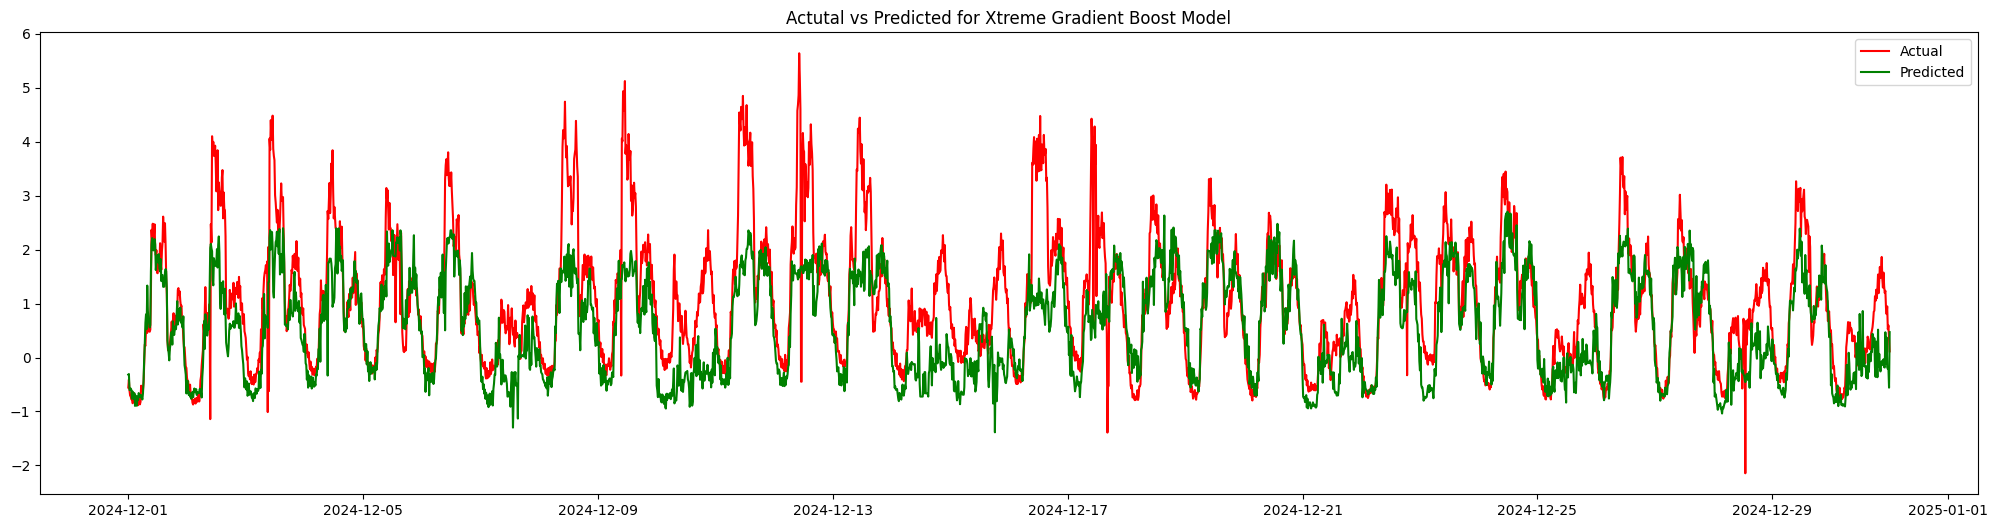


Actual vs Predicted Values:
                       Actual  Predicted
timestamp                               
2024-12-01 00:00:00 -0.555685  -0.316589
2024-12-01 00:15:00 -0.407785  -0.305649
2024-12-01 00:30:00 -0.611148  -0.601390
2024-12-01 00:45:00 -0.705896  -0.600666
2024-12-01 01:00:00 -0.718606  -0.574185
2024-12-01 01:15:00 -0.775224  -0.601348
2024-12-01 01:30:00 -0.771758  -0.763812
2024-12-01 01:45:00 -0.846864  -0.629837
2024-12-01 02:00:00 -0.831842  -0.675967
2024-12-01 02:15:00 -0.655056  -0.765816


In [43]:
models = {
    'Linear Regression':LinearRegression(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=12345),
    'ANN': MLPRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Xtreme Gradient Boost': XGBRegressor()
        }


for name, model in models.items():
    print(f"Evaluating {name}...\n")

    evaluate_model(name,model, X_train, y_train, X_test, y_test)



